# Pricnciple Component Analysis
### The note book implements the PCA on synthetic dataset
#### Last modified at 8 August 2025
#### Ibrahim Radwan

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Create a synthetic dataset
means = [2.13, -99, 0.11, -1.01] # 4 columns with different means
# Covariance matrix - generalization of the concept of variance to the multivariate case 
cov_matrix = np.array([[1, 0.96, 0, 0], [0.96, 1, 0, 0], [0, 0, 1, 0.87], [0, 0, 0.87, 1]]) 
print('Covariance matrix')
print(cov_matrix)

n = 100 # number of rows
dataset = np.random.multivariate_normal(means, cov_matrix, n)
print("\nDataset:\n", dataset)
print("\nDataset shape:\n", dataset.shape)

Covariance matrix
[[1.   0.96 0.   0.  ]
 [0.96 1.   0.   0.  ]
 [0.   0.   1.   0.87]
 [0.   0.   0.87 1.  ]]

Dataset:
 [[ 8.97692621e-01 -1.00251598e+02 -3.83722535e-02 -1.10494299e+00]
 [ 2.43451108e+00 -9.86350151e+01 -4.11987131e-01 -2.10787767e+00]
 [ 3.26960447e+00 -9.77206659e+01  7.75618903e-02 -1.87479925e+00]
 [ 7.07017179e-01 -1.00336732e+02 -1.13260529e+00 -2.06413208e+00]
 [ 3.30960025e+00 -9.76011177e+01 -5.24245761e-01 -6.16098412e-01]
 [-5.45332148e-01 -1.01040310e+02 -5.14071964e-02 -1.38364302e+00]
 [ 2.96286458e+00 -9.84250791e+01  1.22910495e+00 -8.19846976e-01]
 [ 2.25088048e+00 -9.92249078e+01  3.90258005e-03 -1.19369270e+00]
 [ 2.55389938e+00 -9.81940367e+01 -1.09332150e+00 -1.66090082e+00]
 [ 1.99774585e+00 -9.89496841e+01  1.50387868e+00 -2.63167579e-02]
 [ 5.80137132e-01 -1.00012779e+02  3.94019536e-01 -7.31140843e-01]
 [ 3.77506409e+00 -9.79739918e+01  2.06238365e-01 -9.55010866e-01]
 [ 1.35087163e+00 -9.97229542e+01  6.95258288e-03 -1.43756811e+00]
 [ 1.81

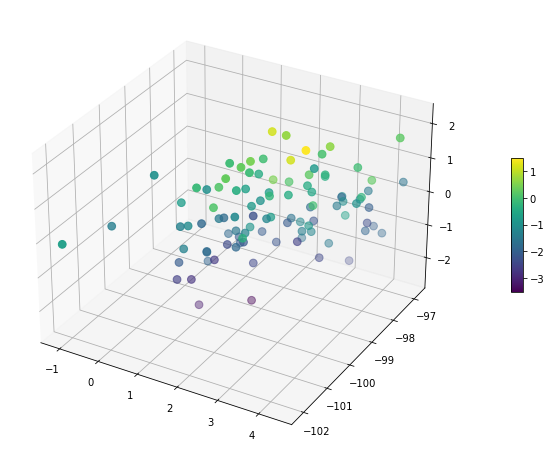

In [3]:
# Let us plot the data
fig = plt.figure(figsize=(8, 16))
ax = fig.add_subplot(111, projection='3d')
img = ax.scatter(xs=dataset[:,0], ys=dataset[:,1], zs=dataset[:,2], c=dataset[:,3], s=60)

cax = fig.add_axes([ax.get_position().x1+0.10, ax.get_position().y0+0.14, 0.02,
                    ax.get_position().height*0.3])
fig.colorbar(img, cax=cax)

plt.show()

### 1. Data standardization

In [4]:
print('Before standardization')
print('Mean:\n',dataset.mean(axis=0))
print('Standard deviation:\n',dataset.std(axis=0))

# Standardization
dataset_standardizated = (dataset - np.mean(dataset, axis=0)) / np.std(dataset, axis=0)

print('\nAfter standardization')
print('Mean:\n',dataset_standardizated.mean(axis=0))
print('Standard deviation:\n',dataset_standardizated.std(axis=0))

Before standardization
Mean:
 [ 2.24019841e+00 -9.89345393e+01  4.85990280e-02 -1.07311272e+00]
Standard deviation:
 [1.04812208 0.97568034 1.00736409 1.01699661]

After standardization
Mean:
 [-2.53130850e-16 -1.18050014e-14 -2.22044605e-18  1.14352972e-16]
Standard deviation:
 [1. 1. 1. 1.]


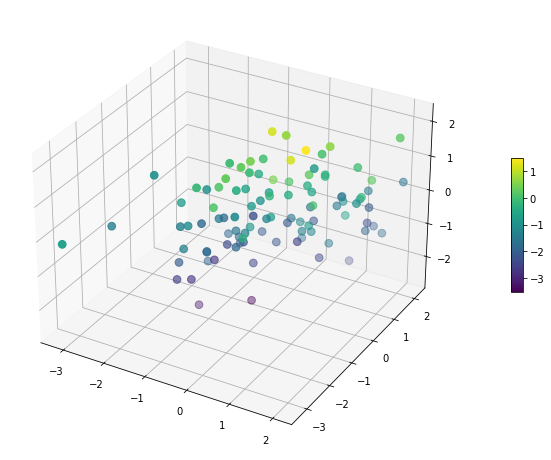

In [5]:
# Let us plot the standardised data
fig = plt.figure(figsize=(8, 16))
ax = fig.add_subplot(111, projection='3d')
img = ax.scatter(xs=dataset_standardizated[:,0], ys=dataset_standardizated[:,1], zs=dataset_standardizated[:,2], c=dataset[:,3], s=60)

cax = fig.add_axes([ax.get_position().x1+0.10, ax.get_position().y0+0.14, 0.02,
                    ax.get_position().height*0.3])
fig.colorbar(img, cax=cax)

plt.show()

### 2. Creating a covariance matrix.

In [6]:
covariance_matrix = np.cov(dataset_standardizated.T)
covariance_matrix

array([[1.01010101, 0.97401639, 0.12347588, 0.12560346],
       [0.97401639, 1.01010101, 0.0721505 , 0.08170672],
       [0.12347588, 0.0721505 , 1.01010101, 0.88774731],
       [0.12560346, 0.08170672, 0.88774731, 1.01010101]])

### 3. Eigen Decomposition.

In [7]:
eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)
print('eigenvalues:\n',eigenvalues,'\n\neigenvectors:\n',eigenvectors)

eigenvalues:
 [2.147452   1.73576292 0.03469811 0.122491  ] 

eigenvectors:
 [[-0.55927608 -0.42995743 -0.70803636 -0.0321151 ]
 [-0.53920165 -0.46072322  0.70444456  0.02745102]
 [-0.44366817  0.55067674  0.04804808 -0.70541127]
 [-0.44680018  0.5473809  -0.01156506  0.70753798]]


### 4. Explained total variance.

[0.531, 0.43, 0.03, 0.009]


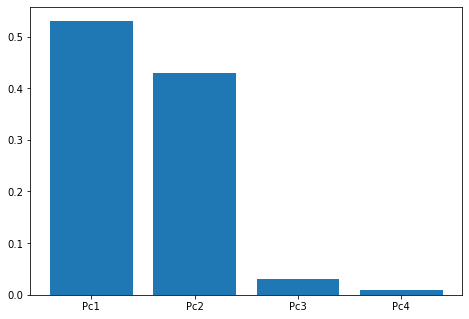

In [8]:
explained_variance = [round((i/np.sum(eigenvalues)), 3) for i in sorted(eigenvalues, reverse=True)]
print(explained_variance)
fig = plt.figure()
ax = fig.add_axes([0,0,1,1])
x_axis_labels = ['Pc1', 'Pc2', 'Pc3', 'Pc4']
ax.bar(x_axis_labels,explained_variance)
plt.show()

### 5. Feature transformation.

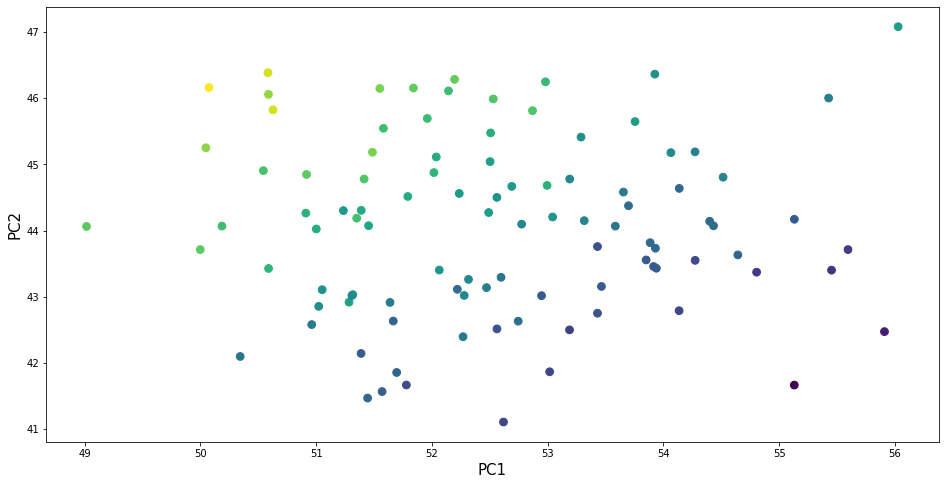

In [21]:
eigenpairs = [(np.abs(eigenvalues[i]), eigenvectors[:, i]) for i in range(len(eigenvalues))]
eigenpairs.sort(key = lambda k: k[0], reverse=True)

eigenpairs

eigenpairs[0][1]

w = np.hstack((eigenpairs[0][1][:, np.newaxis],
               eigenpairs[1][1][:, np.newaxis]))
pc1 = dataset.dot(w.T[0])
pc2 = dataset.dot(w.T[1])

fig = plt.figure(figsize=(16, 8))
ax = fig.add_subplot(111)
ax.scatter(x=pc1, y=pc2, c=dataset[:,3], s=60)
ax.set_xlabel(xlabel='PC1', rotation=0, loc='center', size=15)
ax.set_ylabel(ylabel='PC2', rotation=90, loc='center', size=15)
plt.show()
